<a href="https://colab.research.google.com/github/deadex-ng/arena/blob/main/chapter0_fundamentals/exercises/part3_optimization/RMSProp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [108]:
import numpy as np
import matplotlib.pyplot as plt

In [109]:
def quadratic_loss(x,y):
  return x**2 + 10*y**2

In [110]:
def quadratic_grad(x, y):
  dx = 2*x
  dy = 20*y
  return np.array([dx, dy])

In [111]:
def gradient_descent(grad_func, lr, epochs, start_point):
  x, y = start_point
  path = [(x, y)]
  losses = [quadratic_loss(x,y)]
  for _ in range (epochs):
    grad = grad_func(x,y)
    x -= lr * grad[0]
    y -= lr * grad[1]
    path.append((x,y))
    losses.append(quadratic_loss(x,y))
  return np.array(path), losses

In [112]:
def rmsprop_optimizer(grad_func, lr, beta, epsilon, epochs, start_point):
  x, y = start_point
  Eg2 = np.array([0.0, 0.0])
  path = [(x,y)]
  losses = [quadratic_loss(x,y)]

  for _ in range(epochs):
    grad = grad_func(x,y)
    Eg2 = beta*Eg2 + (1-beta)*(grad**2)
    x -= lr * grad[0]/(np.sqrt(Eg2[0]+epsilon))
    y -= lr * grad[1]/(np.sqrt(Eg2[1]+epsilon))
    path.append((x,y))
    losses.append(quadratic_loss(x,y))

  return np.array(path), losses

In [113]:
def plot_paths(function, paths, labels, title):
    X, Y = np.meshgrid(np.linspace(-2, 2, 400),
                       np.linspace(-2, 2, 400))
    Z = function(X, Y)

    plt.figure(figsize=(8, 6))
    plt.contour(X, Y, Z, levels=50, cmap='jet')

    for path, label in zip(paths, labels):
        plt.plot(path[:, 0], path[:, 1], label=label)
        plt.scatter(path[0, 0], path[0, 1], color='green')
        plt.scatter(path[-1, 0], path[-1, 1], color='red')

_
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()


In [114]:
def plot_losses(losses, labels, title):
  plt.figure(figsize=(8,6))
  for loss, label in zip(losses, labels):
    plt.plot(loss, label=label)

  # plt.title(title)
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

In [115]:
lr_dg = 0.1
lr_rmsprop = 0.1
beta = 0.9
epsilon = 1e-8
epochs = 100
start_point = (1.5, 1.5)

In [116]:
path_gd, losses_gd = gradient_descent(quadratic_grad, lr_dg, epochs, start_point)
path_rmsprop, losses_rmsprop = rmsprop_optimizer(quadratic_grad, lr_rmsprop, beta, epsilon, epochs, start_point)

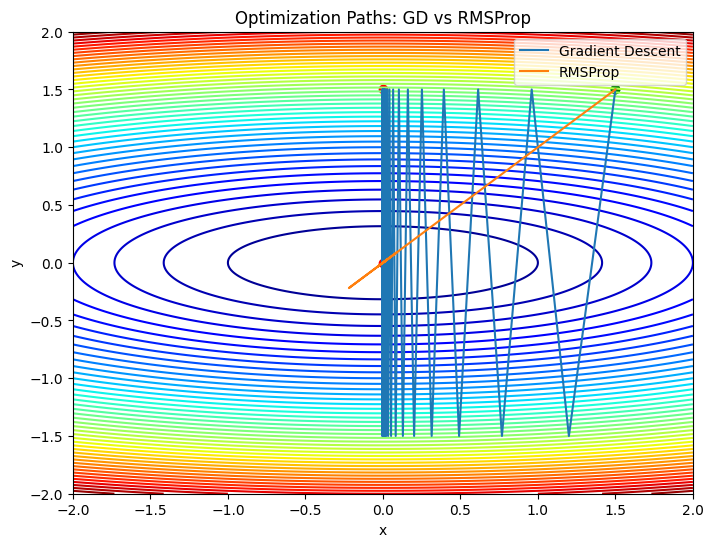

In [117]:
plot_paths(quadratic_loss, [path_gd, path_rmsprop], ["Gradient Descent", "RMSProp"], "Optimization Paths: GD vs RMSProp")

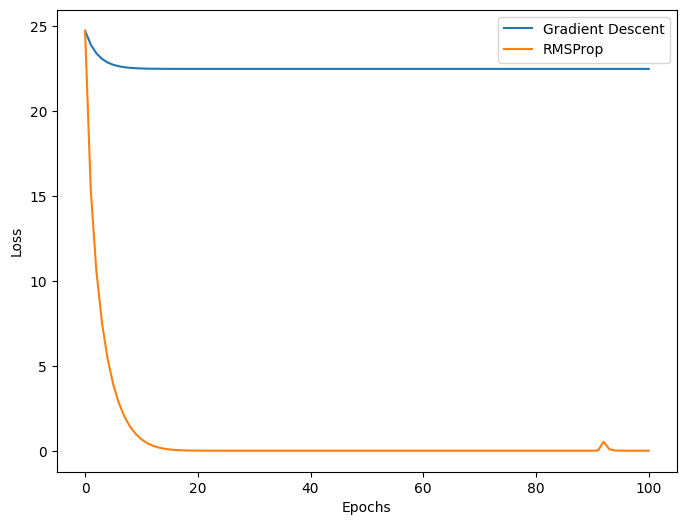

In [118]:
plot_losses([losses_gd, losses_rmsprop], ["Gradient Descent", "RMSProp"], "Loss Vs Epochs: GD vs RMSProp")